In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # vecinos más cercanos para clasificación
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.metrics import classification_report

# Para validación cruzada
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# Análisis Exploratorio

In [2]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
df_smokers.head(5)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [3]:
# verificamos los tipos de datos
df_smokers.dtypes

age                      int64
height(cm)               int64
weight(kg)               int64
waist(cm)              float64
eyesight(left)         float64
eyesight(right)        float64
hearing(left)            int64
hearing(right)           int64
systolic                 int64
relaxation               int64
fasting blood sugar      int64
Cholesterol              int64
triglyceride             int64
HDL                      int64
LDL                      int64
hemoglobin             float64
Urine protein            int64
serum creatinine       float64
AST                      int64
ALT                      int64
Gtp                      int64
dental caries            int64
smoking                  int64
dtype: object

In [4]:
print("Tamaño del dataframe : {}".format(df_smokers.shape))

Tamaño del dataframe : (38984, 23)


In [5]:
# Verificamos si hay valores nulos para imputar
df_smokers.isnull().sum()

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

smoking
0    24666
1    14318
Name: count, dtype: int64


<Axes: xlabel='smoking', ylabel='count'>

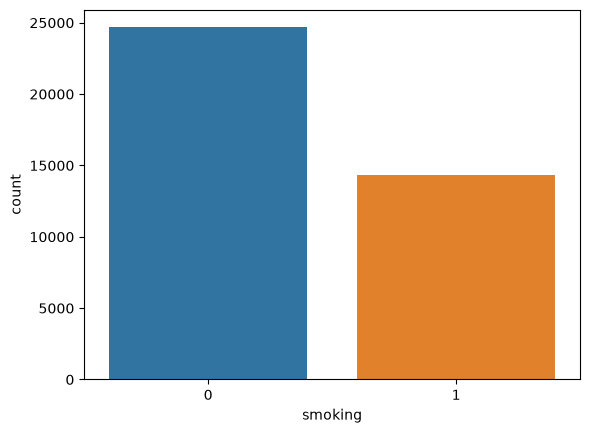

In [6]:
# Analisis de la distribución de la variable target "smoking"
print( df_smokers.smoking.value_counts() )
sns.countplot(x='smoking', data=df_smokers, hue='smoking', legend=False)

[]

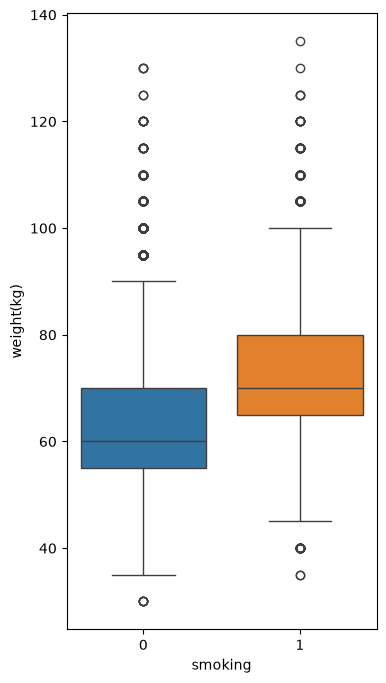

In [7]:
plt.figure(figsize=(4, 8))
s=sns.boxplot(x="smoking", y="weight(kg)", data=df_smokers, hue="smoking", legend=False)
s.plot()

# Correlación de Variables

<Axes: >

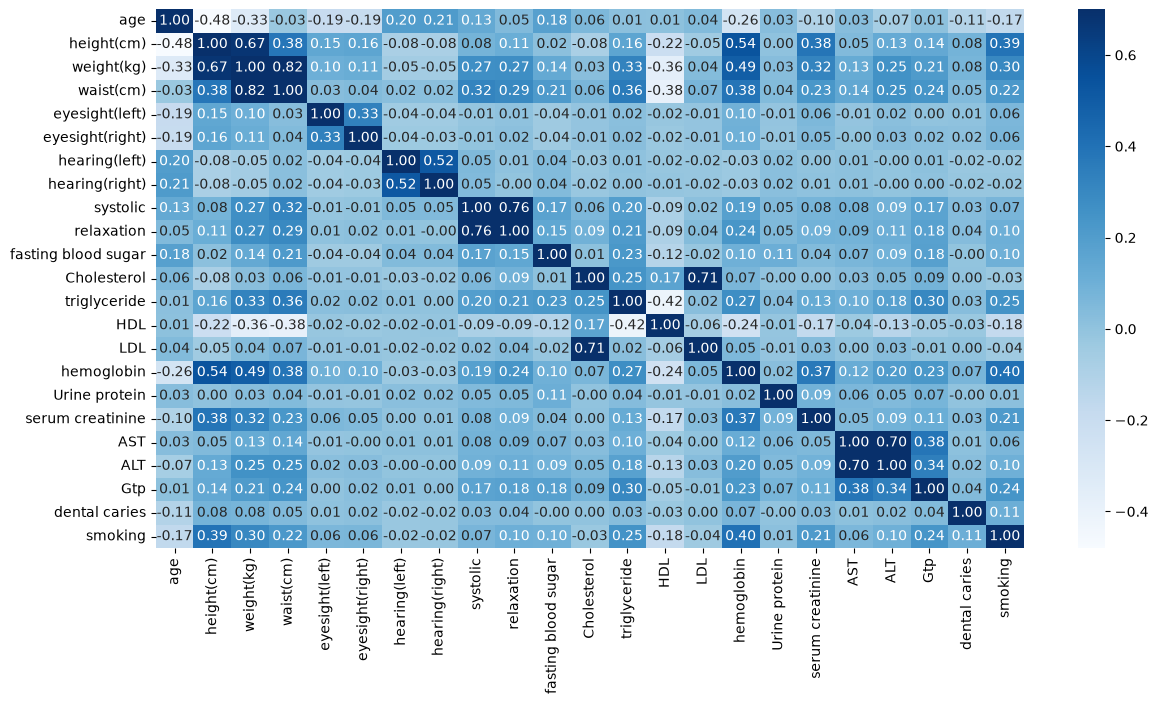

In [8]:
plt.figure(figsize=(14,7))
sns.heatmap(df_smokers.corr(), annot=True, vmax=.7, cmap ='Blues', fmt=".2f")

In [9]:
df_smokers_corr = df_smokers.corr()[["smoking"]]*100 # lo pasamos a porcentajes
df_smokers_corr = df_smokers_corr.drop("smoking", axis=0) # eliminamos la variable target
df_smokers_corr = df_smokers_corr.sort_values(["smoking"], ascending=False) # ordenamos en forma descendente
df_smokers_corr = abs(df_smokers_corr) # nos interesa el valor absouluto
df_smokers_corr

,smoking
hemoglobin,40.120561
height(cm),39.431445
weight(kg),29.934668
triglyceride,25.105661
Gtp,24.027443
waist(cm),22.335903
serum creatinine,21.247301
dental caries,10.760060
relaxation,10.366297
fasting blood sugar,9.990846


# Seleccionamos y Escalamos las variables que vamos a utilizar

In [10]:
# definimos df con las 10 columnas que elegimos para el modelo
# sería lo mismo que hacer un drop de las que no queremos
df = df_smokers[['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
       'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
       'fasting blood sugar','smoking']]

df = df_smokers[[ 'weight(kg)',
       'dental caries', 'relaxation'
      ,'smoking']]

In [11]:
# Hacemos el Split 70-30 para train-test
y_smokers = df["smoking"]
X_train, X_test, y_train, y_test = train_test_split(df.drop(["smoking"],axis = 1), y_smokers, test_size=0.3, stratify = y_smokers, random_state=42)

In [12]:
# usamos StandardScaler para escalar las variables
scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

StandardScaler()

In [13]:
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

In [14]:
test_scores = []

# Creamos y entrenamos el algoritmo con 20 valores de K
for k in range(3,40,2):
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  test_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación

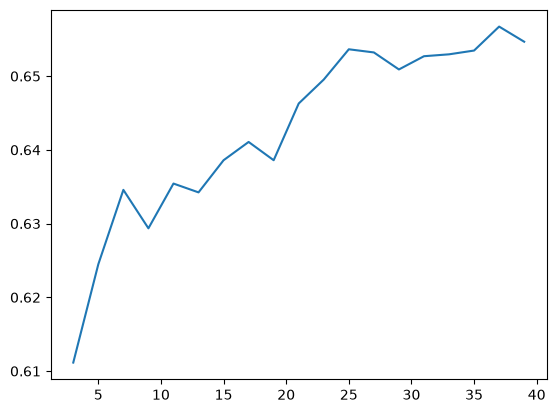

In [15]:
df_scores = pd.DataFrame([{"k":valor_k, "score":test_scores_k} for valor_k, test_scores_k in zip(range(3,40,2),test_scores)])
plt.plot(df_scores["k"], df_scores["score"])

In [16]:
df_scores

,k,score
0,3,0.611149
1,5,0.624487
2,7,0.634576
3,9,0.629360
4,11,0.635431
5,13,0.634234
6,15,0.638594
7,17,0.641074
8,19,0.638594
9,21,0.646289


In [17]:
# Entrenamos el algoritmo con el mejor K
knn = KNeighborsClassifier( 11 )
knn.fit(X_train,y_train) # Entrenamos el clasificador

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [18]:
y_pred_knn = knn.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

Exactitud (accuracy) del modelo: 63.54 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      7400
           1       0.51      0.37      0.43      4296

    accuracy                           0.64     11696
   macro avg       0.59      0.58      0.58     11696
weighted avg       0.62      0.64      0.62     11696



# Ejercicio
Dado el análisis exploratorio concluimos que no hace falta imputar variables y que la variable target esta balanceada.
- Usando el mapa de calor de correlaciones, ¿que pares de columnas comparten más de un 0.7 de correlación?
- Entrenar un modelo con K distinto a 11, comparar los resultados
- Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados
- Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados
- "Feature Engineering", Crear una columna nueva no redundante, entrenar un modelo y comparar los resultados

In [19]:
correlacion = df_smokers.corr()
correlacion[(correlacion>0.7) & (correlacion<1) | (correlacion< -0.7) & (correlacion> -1)].dropna(how='all', axis=0).dropna(how='all', axis=1).dropna(how='all', axis=0)

,weight(kg),waist(cm),systolic,relaxation,Cholesterol,LDL
weight(kg),NaN,0.824865,NaN,NaN,NaN,NaN
waist(cm),0.824865,NaN,NaN,NaN,NaN,NaN
systolic,NaN,NaN,NaN,0.759041,NaN,NaN
relaxation,NaN,NaN,0.759041,NaN,NaN,NaN
Cholesterol,NaN,NaN,NaN,NaN,NaN,0.70704
LDL,NaN,NaN,NaN,NaN,0.70704,NaN


In [20]:
# Entrenamos el algoritmo con el mejor K
knn20 = KNeighborsClassifier( 20 )
knn20.fit(X_train,y_train) # Entrenamos el clasificador

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [21]:
y_pred_knn20 = knn20.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn20)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn20))

Exactitud (accuracy) del modelo: 64.66 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      7400
           1       0.51      0.37      0.43      4296

    accuracy                           0.64     11696
   macro avg       0.59      0.58      0.58     11696
weighted avg       0.62      0.64      0.62     11696

              precision    recall  f1-score   support

           0       0.68      0.83      0.75      7400
           1       0.53      0.33      0.41      4296

    accuracy                           0.65     11696
   macro avg       0.61      0.58      0.58     11696
weighted avg       0.63      0.65      0.62     11696



In [22]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(knn20, X_test, y_test, n_repeats=5, random_state=42, )

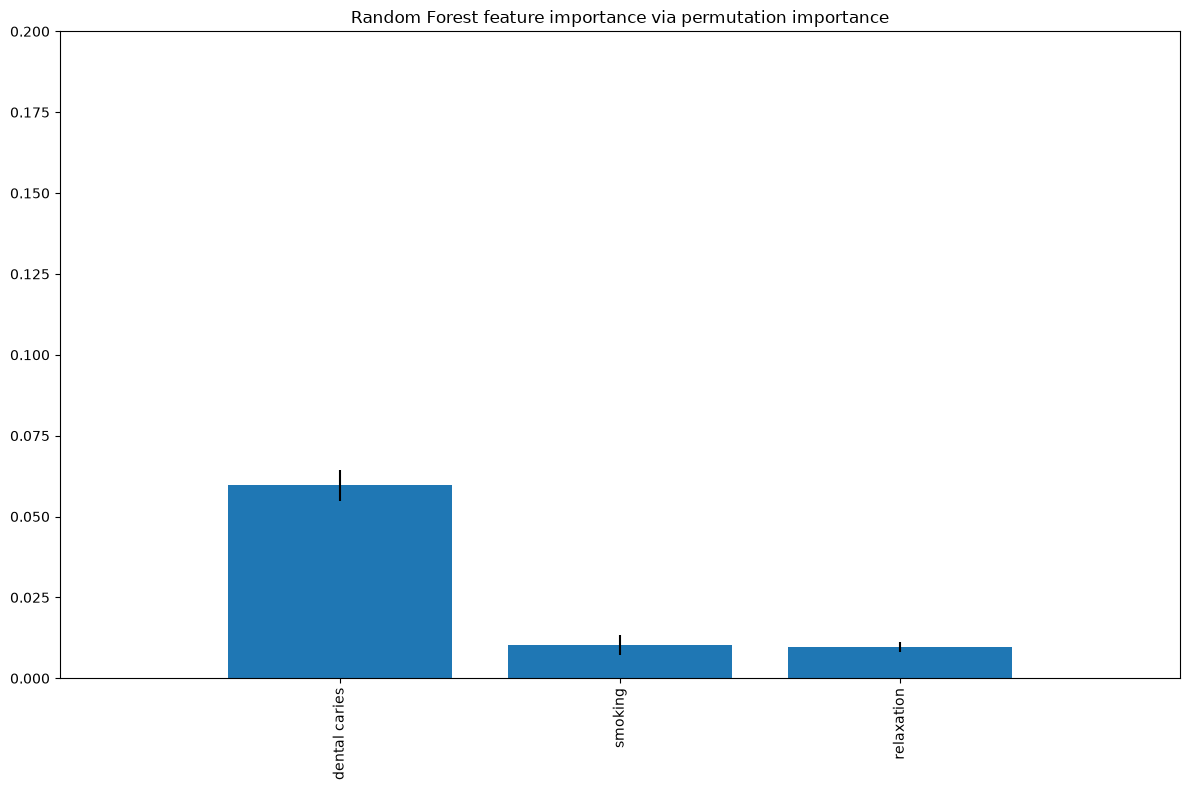

In [23]:
import numpy as np
indices = np.argsort(perm['importances_mean'])[::-1]
 
plt.figure(figsize=(12, 8))
plt.title("Random Forest feature importance via permutation importance")
plt.bar(
    range(X_train.shape[1]),
    perm['importances_mean'][indices],
    yerr=perm['importances_std'][indices]
)
 
feature_names = np.array(list(df.columns[1:])+['random'])
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.ylim([0, 0.2])
 
plt.tight_layout()
plt.show()

## Resumen de los puntos 1 y 2

**Pares con |correlación| > 0.7** (celda de arriba):
- `weight(kg)` – `waist(cm)`: 0.82
- `systolic` – `relaxation`: 0.76
- `Cholesterol` – `LDL`: 0.71

Son pares **redundantes**: aportan casi la misma información. En KNN esto es especialmente molesto porque la distancia euclídea cuenta dos veces el mismo concepto (le da doble peso). Conviene quedarse con una de cada par.

**K = 11 vs K = 20**: la accuracy sube de 63.54 % a 64.66 %. Con K más grande la frontera de decisión se suaviza (menos varianza), sube el recall de la clase 0 pero baja el de la clase 1: el modelo se vuelve más conservador y predice "no fumador" más seguido.

Según la *permutation importance*, de las 3 variables actuales la que más aporta es `weight(kg)`, seguida de `relaxation` y `dental caries`.

---

# Función auxiliar con validación cruzada

Para no repetir el mismo código en cada punto, armamos una función que hace todo el pipeline. Usa **validación cruzada** en vez de elegir K mirando el test:

### ¿Por qué validación cruzada?
Antes elegíamos K probando cada valor sobre el test set y quedándonos con el mejor. Eso es **hacer trampa sin querer**: usamos el test para tomar una decisión y después reportamos la métrica sobre esos mismos datos, así que el resultado sale optimista. El test deja de ser una estimación honesta de cómo anda el modelo con datos nuevos.

La solución es partir train en K pliegues (*folds*):
1. `train_test_split` separa el 30 % de test y **no lo tocamos hasta el final**.
2. Sobre el 70 % de train, `StratifiedKFold` con 5 pliegues: entrena con 4 y valida con 1, rotando. Cada K obtiene 5 scores, y promediamos.
3. El K ganador se reentrena con todo el train.
4. Recién ahí medimos **una sola vez** sobre el test.

`Stratified` mantiene la proporción de fumadores en cada pliegue.

### El escalado va DENTRO del Pipeline
Detalle clave: si escalamos antes de la validación cruzada, la media y el desvío se calculan usando también las filas que después serán de validación → *data leakage*. Metiendo el `StandardScaler` en un `Pipeline`, sklearn lo reajusta dentro de cada pliegue usando solo los datos de entrenamiento de ese pliegue.

In [24]:
import numpy as np
from sklearn.metrics import f1_score

# Acá vamos guardando el resultado de cada experimento para compararlos al final
resultados = []

# 5 pliegues estratificados: mantienen la proporción de fumadores en cada uno
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluar_knn(datos, nombre, ks=range(3, 102, 4), target="smoking", graficar=True):
    """Entrena KNN eligiendo el mejor K por validación cruzada sobre train.

    El test set NO se usa para elegir K: solo para la evaluación final.
    Devuelve (mejor_modelo, X_test, y_test).
    """
    y = datos[target]
    X = datos.drop(columns=[target])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # El scaler va DENTRO del pipeline: así se reajusta en cada pliegue de la CV
    # y no filtra información del fold de validación.
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ])

    ks = list(ks)
    grid = GridSearchCV(
        pipe,
        param_grid={"knn__n_neighbors": ks},
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )
    grid.fit(X_train, y_train)  # la CV ocurre solo acá adentro, sobre train

    mejor_k = grid.best_params_["knn__n_neighbors"]
    cv_media = grid.best_score_
    cv_std = grid.cv_results_["std_test_score"][grid.best_index_]

    if graficar:
        medias = grid.cv_results_["mean_test_score"]
        stds = grid.cv_results_["std_test_score"]
        medias_train = grid.cv_results_["mean_train_score"]

        plt.figure(figsize=(8, 4.5))
        # Banda de ±1 desvío entre pliegues: muestra cuán estable es cada K
        plt.fill_between(ks, medias - stds, medias + stds, alpha=0.2, color="#2a9d8f")
        plt.plot(ks, medias, marker="o", markersize=3, color="#2a9d8f", label="validación (CV)")
        plt.plot(ks, medias_train, linestyle=":", color="#e76f51", label="train")
        plt.axvline(mejor_k, color="red", linestyle="--", label=f"mejor K = {mejor_k}")
        plt.xlabel("K")
        plt.ylabel("accuracy")
        plt.title(f"{nombre} — {X.shape[1]} variables (CV 5-fold)")
        plt.legend()
        plt.show()

    # El mejor modelo ya viene reentrenado con todo el train (refit=True por defecto)
    modelo = grid.best_estimator_
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"--- {nombre} ---")
    print(f"Variables usadas ({X.shape[1]}): {list(X.columns)}")
    print(f"Mejor K (elegido por CV): {mejor_k}")
    if mejor_k in (ks[0], ks[-1]):
        print("[aviso] el mejor K cae en el borde de la grilla: conviene ampliarla")
    print(f"Accuracy en validación cruzada: {cv_media * 100:.2f} % (+/- {cv_std * 100:.2f})")
    print(f"Accuracy en TEST (datos nunca vistos): {acc * 100:.2f} %")
    print(f"Diferencia CV - test: {(cv_media - acc) * 100:+.2f} puntos\n")
    print(classification_report(y_test, y_pred))

    resultados.append({
        "modelo": nombre,
        "n_variables": X.shape[1],
        "K": mejor_k,
        "cv_accuracy": round(cv_media * 100, 2),
        "cv_std": round(cv_std * 100, 2),
        "test_accuracy": round(acc * 100, 2),
        "f1_fumador": round(f1_score(y_test, y_pred, pos_label=1) * 100, 2),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro") * 100, 2),
    })

    return modelo, X_test, y_test

---
# Punto 3 — Modelo con 3 variables

El modelo original usaba `weight(kg)`, `dental caries` y `relaxation`, que **no** son las 3 más correlacionadas con el target. Si miramos la tabla de correlaciones con `smoking`, las 3 mejores son:

| variable | correlación con smoking |
|---|---|
| hemoglobin | 40.1 % |
| height(cm) | 39.4 % |
| weight(kg) | 29.9 % |

Además ninguna de las tres forma parte de los pares redundantes (>0.7) que encontramos, así que las podemos usar juntas sin duplicar información.

In [25]:
# Primero volvemos a registrar el modelo base (3 variables originales) para tenerlo en la comparación
# Con pocas variables el K óptimo es grande, así que usamos una grilla más amplia
df_base = df_smokers[["weight(kg)", "dental caries", "relaxation", "smoking"]]
_ = evaluar_knn(df_base, "Base (3 vars originales)", ks=range(5, 302, 10), graficar=False)

--- Base (3 vars originales) ---
Variables usadas (3): ['weight(kg)', 'dental caries', 'relaxation']
Mejor K (elegido por CV): 285
Accuracy en validación cruzada: 65.82 % (+/- 0.48)
Accuracy en TEST (datos nunca vistos): 65.77 %
Diferencia CV - test: +0.05 puntos

              precision    recall  f1-score   support

           0       0.69      0.84      0.76      7400
           1       0.55      0.35      0.43      4296

    accuracy                           0.66     11696
   macro avg       0.62      0.59      0.59     11696
weighted avg       0.64      0.66      0.64     11696



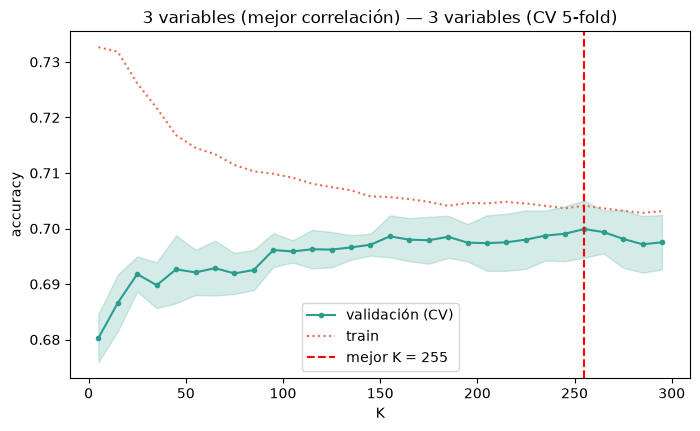

--- 3 variables (mejor correlación) ---
Variables usadas (3): ['hemoglobin', 'height(cm)', 'weight(kg)']
Mejor K (elegido por CV): 255
Accuracy en validación cruzada: 69.99 % (+/- 0.51)
Accuracy en TEST (datos nunca vistos): 69.49 %
Diferencia CV - test: +0.51 puntos

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      7400
           1       0.56      0.75      0.64      4296

    accuracy                           0.69     11696
   macro avg       0.69      0.71      0.69     11696
weighted avg       0.73      0.69      0.70     11696



In [26]:
# Las 3 variables más correlacionadas con el target
# Grilla amplia: con solo 3 dimensiones el vecindario óptimo es grande
df_3vars = df_smokers[["hemoglobin", "height(cm)", "weight(kg)", "smoking"]]
modelo_3, _, _ = evaluar_knn(df_3vars, "3 variables (mejor correlación)", ks=range(5, 302, 10))

---
# Punto 4 — Modelo con todas las variables

Usamos las 22 variables predictoras. Ojo con la **maldición de la dimensionalidad**: en muchas dimensiones todos los puntos quedan aproximadamente a la misma distancia entre sí, y la noción de "vecino cercano" pierde sentido. Por eso más variables no siempre significa mejor KNN.

También probamos una variante sin las columnas redundantes del punto 1 (sacamos `waist(cm)`, `systolic` y `LDL`, quedándonos con una de cada par) para ver si limpiar la redundancia ayuda.

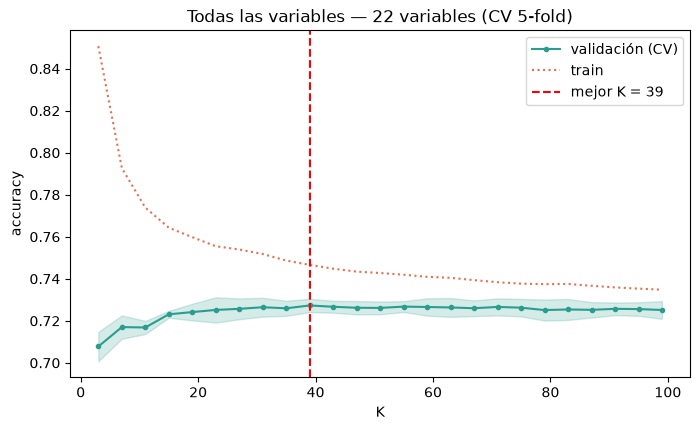

--- Todas las variables ---
Variables usadas (22): ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']
Mejor K (elegido por CV): 39
Accuracy en validación cruzada: 72.73 % (+/- 0.32)
Accuracy en TEST (datos nunca vistos): 72.61 %
Diferencia CV - test: +0.13 puntos

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      7400
           1       0.63      0.60      0.62      4296

    accuracy                           0.73     11696
   macro avg       0.70      0.70      0.70     11696
weighted avg       0.72      0.73      0.72     11696



In [27]:
# Todas las variables del dataset
# Ampliamos la grilla de K: con 22 variables el mejor K se iba al borde de range(3,52,2)
modelo_todas, _, _ = evaluar_knn(df_smokers, "Todas las variables", ks=range(3, 102, 4))

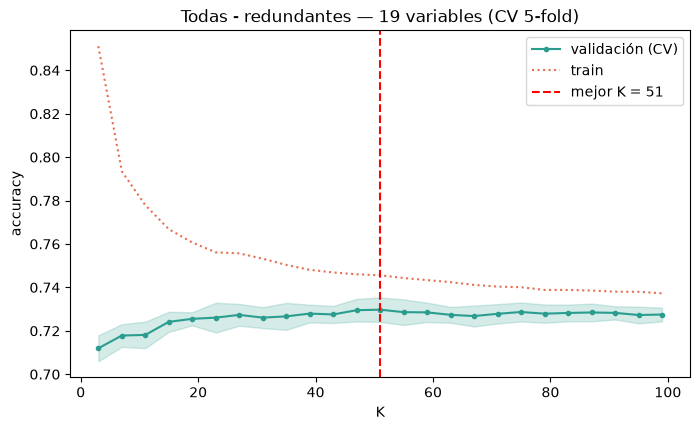

--- Todas - redundantes ---
Variables usadas (19): ['age', 'height(cm)', 'weight(kg)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']
Mejor K (elegido por CV): 51
Accuracy en validación cruzada: 72.97 % (+/- 0.56)
Accuracy en TEST (datos nunca vistos): 72.44 %
Diferencia CV - test: +0.54 puntos

              precision    recall  f1-score   support

           0       0.78      0.79      0.78      7400
           1       0.63      0.60      0.62      4296

    accuracy                           0.72     11696
   macro avg       0.70      0.70      0.70     11696
weighted avg       0.72      0.72      0.72     11696



In [28]:
# Todas las variables, pero sacando una de cada par redundante (corr > 0.7)
redundantes = ["waist(cm)", "systolic", "LDL"]
df_sin_redundantes = df_smokers.drop(columns=redundantes)
_ = evaluar_knn(df_sin_redundantes, "Todas - redundantes", ks=range(3, 102, 4))

---
# Punto 5 — Feature Engineering

Creamos columnas nuevas que **no sean redundantes**, es decir, que combinen variables existentes en una relación que el modelo no puede "ver" solo con las originales (KNN no multiplica ni divide variables: solo mide distancias).

Propuestas:

1. **`IMC`** = peso / altura² — el índice de masa corporal es un cociente, no una combinación lineal, así que aporta información nueva respecto de tener peso y altura por separado.
2. **`ratio_cintura_altura`** = cintura / altura — indicador de obesidad abdominal, mejor predictor de riesgo metabólico que la cintura sola.
3. **`ratio_colesterol`** = Cholesterol / HDL — ratio clásico de riesgo cardiovascular.
4. **`ratio_higado`** = AST / ALT — el cociente De Ritis, marcador de daño hepático asociado al consumo de alcohol y tabaco.
5. **`presion_pulso`** = systolic − relaxation — la diferencia entre ambas presiones, que resuelve elegantemente el par redundante (0.76): en vez de descartar una, combinamos ambas en algo con sentido clínico.

Verificamos que las nuevas columnas no estén demasiado correlacionadas con las originales antes de usarlas.

In [29]:
df_fe = df_smokers.copy()

# 1) IMC = peso / altura^2  (altura pasada a metros)
df_fe["IMC"] = df_fe["weight(kg)"] / (df_fe["height(cm)"] / 100) ** 2

# 2) Obesidad abdominal relativa a la altura
df_fe["ratio_cintura_altura"] = df_fe["waist(cm)"] / df_fe["height(cm)"]

# 3) Riesgo cardiovascular
df_fe["ratio_colesterol"] = df_fe["Cholesterol"] / df_fe["HDL"]

# 4) Cociente De Ritis (daño hepático)
df_fe["ratio_higado"] = df_fe["AST"] / df_fe["ALT"]

# 5) Presión de pulso: combina el par redundante systolic/relaxation
df_fe["presion_pulso"] = df_fe["systolic"] - df_fe["relaxation"]

nuevas = ["IMC", "ratio_cintura_altura", "ratio_colesterol", "ratio_higado", "presion_pulso"]

# Correlación de las nuevas columnas con el target (en %)
corr_nuevas = (df_fe.corr()["smoking"] * 100).abs()[nuevas].sort_values(ascending=False)
print("Correlación de las variables nuevas con smoking (%):")
print(corr_nuevas.round(2))

Correlación de las variables nuevas con smoking (%):
ratio_higado            17.53
ratio_colesterol        15.10
IMC                     10.55
ratio_cintura_altura     2.93
presion_pulso            0.49
Name: smoking, dtype: float64


Máxima correlación absoluta de cada variable nueva contra las originales:

                   IMC -> weight(kg) (0.82)
  ratio_cintura_altura -> waist(cm) (0.87)
      ratio_colesterol -> HDL (0.70)
          ratio_higado -> weight(kg) (0.43)
         presion_pulso -> systolic (0.71)


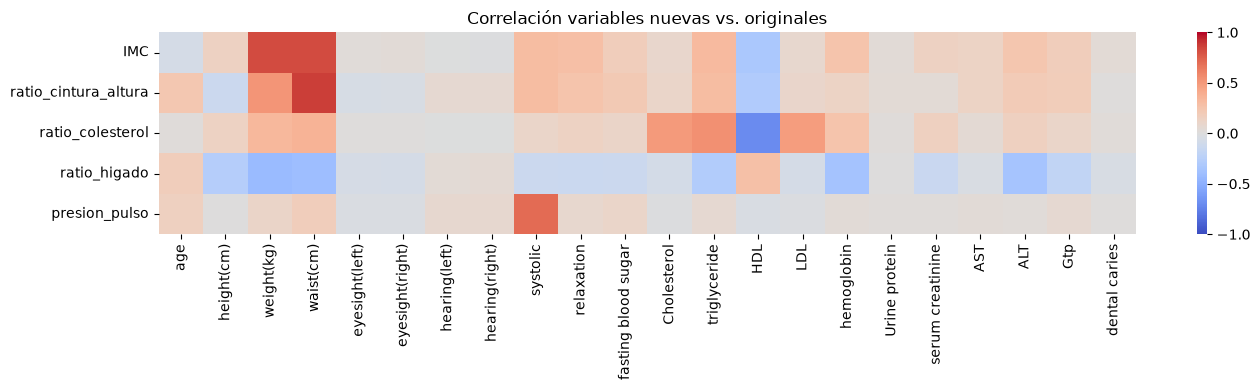

In [30]:
# Chequeo de NO redundancia: ¿alguna variable nueva está muy correlacionada con una original?
originales = [c for c in df_smokers.columns if c != "smoking"]
chequeo = df_fe.corr().loc[nuevas, originales]

print("Máxima correlación absoluta de cada variable nueva contra las originales:\n")
for col in nuevas:
    fila = chequeo.loc[col].abs().sort_values(ascending=False)
    print(f"{col:>22} -> {fila.index[0]} ({fila.iloc[0]:.2f})")

plt.figure(figsize=(14, 4))
sns.heatmap(chequeo, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlación variables nuevas vs. originales")
plt.tight_layout()
plt.show()

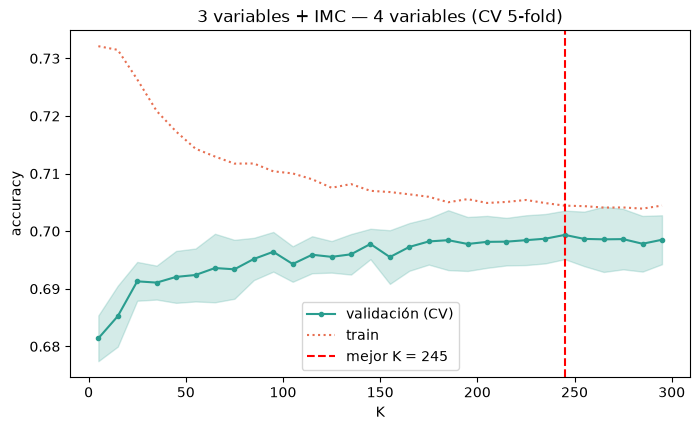

--- 3 variables + IMC ---
Variables usadas (4): ['hemoglobin', 'height(cm)', 'weight(kg)', 'IMC']
Mejor K (elegido por CV): 245
Accuracy en validación cruzada: 69.94 % (+/- 0.42)
Accuracy en TEST (datos nunca vistos): 69.37 %
Diferencia CV - test: +0.56 puntos

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      7400
           1       0.56      0.75      0.64      4296

    accuracy                           0.69     11696
   macro avg       0.69      0.71      0.69     11696
weighted avg       0.73      0.69      0.70     11696



In [31]:
# a) Las 3 mejores variables + el IMC (modelo chico, fácil de interpretar)
df_fe_3 = df_fe[["hemoglobin", "height(cm)", "weight(kg)", "IMC", "smoking"]]
_ = evaluar_knn(df_fe_3, "3 variables + IMC", ks=range(5, 302, 10))

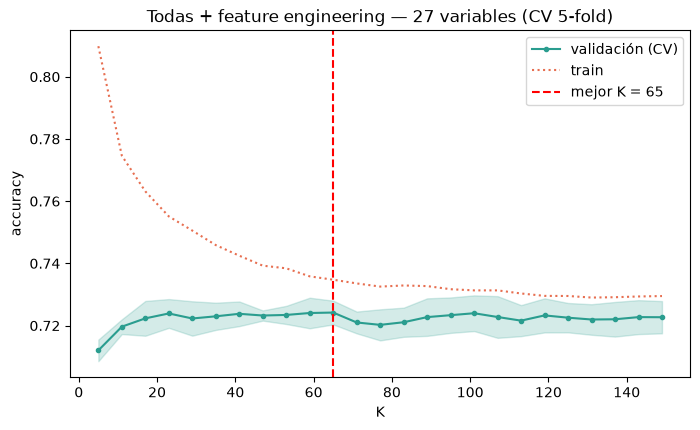

--- Todas + feature engineering ---
Variables usadas (27): ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'IMC', 'ratio_cintura_altura', 'ratio_colesterol', 'ratio_higado', 'presion_pulso']
Mejor K (elegido por CV): 65
Accuracy en validación cruzada: 72.42 % (+/- 0.38)
Accuracy en TEST (datos nunca vistos): 71.89 %
Diferencia CV - test: +0.53 puntos

              precision    recall  f1-score   support

           0       0.77      0.80      0.78      7400
           1       0.63      0.58      0.60      4296

    accuracy                           0.72     11696
   macro avg       0.70      0.69      0.69     11696
weighted avg       0.71      0.72      0.72     11696



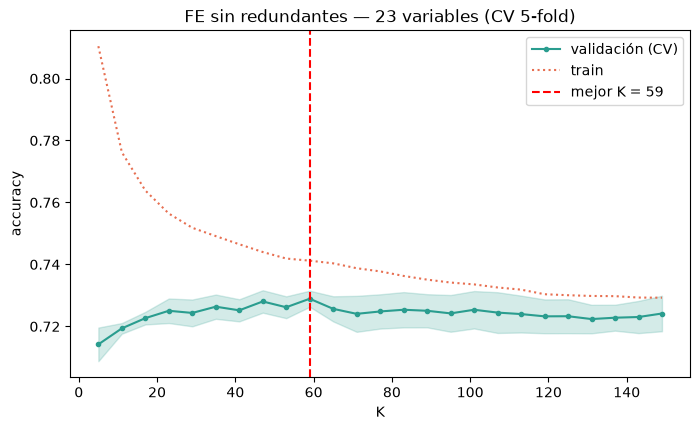

--- FE sin redundantes ---
Variables usadas (23): ['age', 'height(cm)', 'weight(kg)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'IMC', 'ratio_cintura_altura', 'ratio_colesterol', 'ratio_higado', 'presion_pulso']
Mejor K (elegido por CV): 59
Accuracy en validación cruzada: 72.89 % (+/- 0.26)
Accuracy en TEST (datos nunca vistos): 72.43 %
Diferencia CV - test: +0.47 puntos

              precision    recall  f1-score   support

           0       0.77      0.80      0.79      7400
           1       0.63      0.59      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.70      0.70      0.70     11696
weighted avg       0.72      0.72      0.72     11696



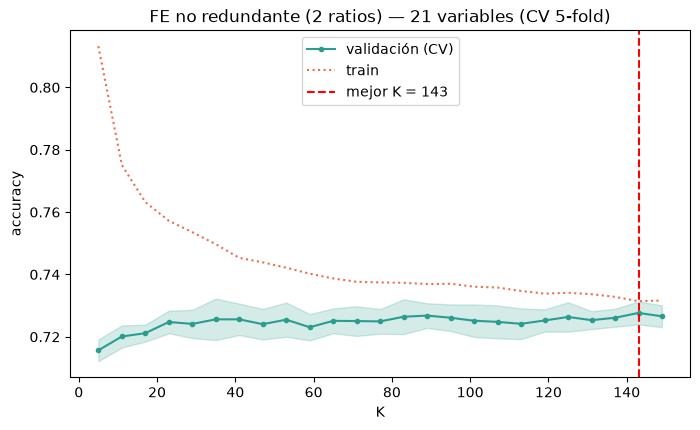

--- FE no redundante (2 ratios) ---
Variables usadas (21): ['age', 'height(cm)', 'weight(kg)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'ratio_higado', 'ratio_colesterol']
Mejor K (elegido por CV): 143
Accuracy en validación cruzada: 72.76 % (+/- 0.37)
Accuracy en TEST (datos nunca vistos): 72.35 %
Diferencia CV - test: +0.42 puntos

              precision    recall  f1-score   support

           0       0.77      0.81      0.79      7400
           1       0.64      0.58      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.70      0.69      0.70     11696
weighted avg       0.72      0.72      0.72     11696



In [32]:
# b) Todas las variables + las 5 nuevas
_ = evaluar_knn(df_fe, "Todas + feature engineering", ks=range(5, 152, 6))

# c) Versión "limpia": sacamos las redundantes y nos quedamos con las features derivadas
df_fe_limpio = df_fe.drop(columns=["waist(cm)", "systolic", "relaxation", "LDL"])
_ = evaluar_knn(df_fe_limpio, "FE sin redundantes", ks=range(5, 152, 6))

# d) Solo las 2 features nuevas que SÍ pasaron el chequeo de no-redundancia
#    (ratio_higado 0.43 y ratio_colesterol 0.70 contra las originales)
df_fe_ok = df_smokers.copy()
df_fe_ok["ratio_higado"] = df_fe["ratio_higado"]
df_fe_ok["ratio_colesterol"] = df_fe["ratio_colesterol"]
df_fe_ok = df_fe_ok.drop(columns=["waist(cm)", "systolic", "LDL"])
_ = evaluar_knn(df_fe_ok, "FE no redundante (2 ratios)", ks=range(5, 152, 6))

---
# Comparación final de todos los modelos

,modelo,n_variables,K,cv_accuracy,cv_std,test_accuracy,f1_fumador,f1_macro
0,Todas - redundantes,19,51,72.97,0.56,72.44,61.67,70.08
1,FE sin redundantes,23,59,72.89,0.26,72.43,61.08,69.87
2,FE no redundante (2 ratios),21,143,72.76,0.37,72.35,60.59,69.65
3,Todas las variables,22,39,72.73,0.32,72.61,61.76,70.21
4,Todas + feature engineering,27,65,72.42,0.38,71.89,60.09,69.20
5,3 variables (mejor correlación),3,255,69.99,0.51,69.49,64.43,68.86
6,3 variables + IMC,4,245,69.94,0.42,69.37,64.32,68.75
7,Base (3 vars originales),3,285,65.82,0.48,65.77,42.71,59.15


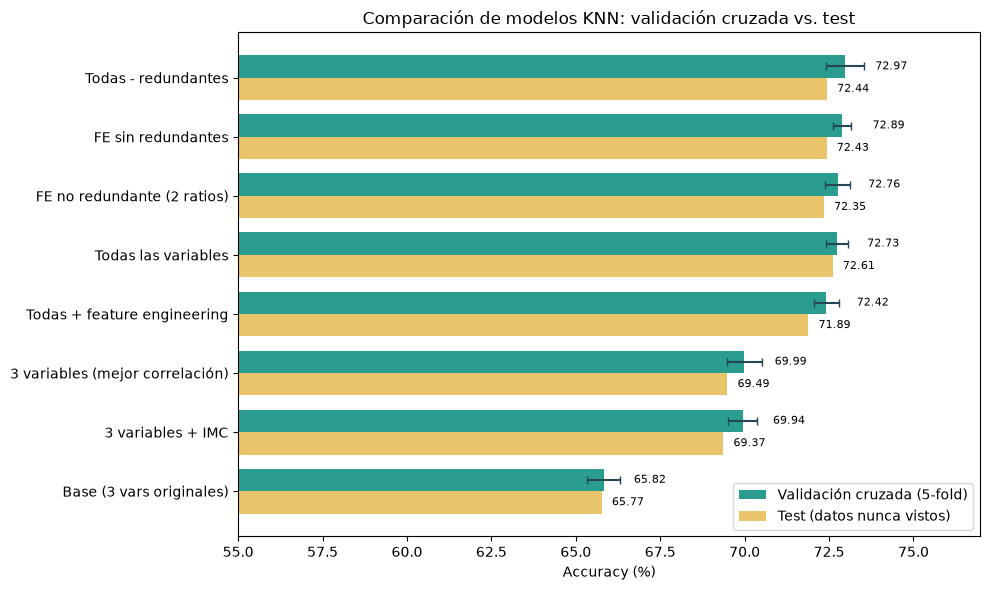

Diferencia media |CV - test|: 0.40 puntos


In [33]:
df_resultados = pd.DataFrame(resultados).sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
display(df_resultados)

# Comparamos accuracy de CV (con su barra de error entre pliegues) contra la de test
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(df_resultados))
altura = 0.38

ax.barh(y_pos - altura/2, df_resultados["cv_accuracy"], altura,
        xerr=df_resultados["cv_std"], color="#2a9d8f", label="Validación cruzada (5-fold)",
        error_kw={"ecolor": "#264653", "capsize": 3})
ax.barh(y_pos + altura/2, df_resultados["test_accuracy"], altura,
        color="#e9c46a", label="Test (datos nunca vistos)")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_resultados["modelo"])
ax.invert_yaxis()
ax.set_xlim(55, max(df_resultados["cv_accuracy"].max(), df_resultados["test_accuracy"].max()) + 4)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Comparación de modelos KNN: validación cruzada vs. test")
ax.legend(loc="lower right")

for i, (cv_v, te_v) in enumerate(zip(df_resultados["cv_accuracy"], df_resultados["test_accuracy"])):
    ax.text(cv_v + 0.9, i - altura/2, f"{cv_v:.2f}", va="center", fontsize=8)
    ax.text(te_v + 0.3, i + altura/2, f"{te_v:.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Si la CV es un buen estimador, las dos columnas deberían parecerse
print("Diferencia media |CV - test|: {:.2f} puntos".format(
    (df_resultados["cv_accuracy"] - df_resultados["test_accuracy"]).abs().mean()))

---
## ¿Cuánto sesgo tenía elegir K mirando el test?

Comparación directa de los dos métodos sobre el mismo modelo, para medir el problema en lugar de solo mencionarlo:

- **Método A (el anterior)**: probar todos los K sobre el test y quedarse con el mejor score. Por construcción toma el máximo de ~25 mediciones ruidosas, así que captura ruido favorable.
- **Método B (correcto)**: elegir K por CV sobre train y reportar el test una sola vez.

Si A da consistentemente más que B, esa diferencia es el **sesgo de selección** que nos estábamos comiendo.

In [34]:
def comparar_metodos(datos, nombre, ks=range(5, 302, 10), target="smoking"):
    """Compara elegir K mirando el test (método viejo) vs. elegirlo por CV."""
    y = datos[target]
    X = datos.drop(columns=[target])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    ks = list(ks)

    pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

    # Método A: elegir K mirando el test
    scores_test = []
    for k in ks:
        pipe.set_params(knn__n_neighbors=k)
        pipe.fit(X_train, y_train)
        scores_test.append(accuracy_score(y_test, pipe.predict(X_test)))
    k_a = ks[int(np.argmax(scores_test))]
    acc_a = max(scores_test)

    # Método B: elegir K por CV sobre train, medir una sola vez en test
    grid = GridSearchCV(pipe, {"knn__n_neighbors": ks}, cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    k_b = grid.best_params_["knn__n_neighbors"]
    acc_b = accuracy_score(y_test, grid.best_estimator_.predict(X_test))

    return {
        "modelo": nombre,
        "K (test)": k_a, "acc reportada (test)": round(acc_a * 100, 2),
        "K (CV)": k_b, "acc honesta (CV)": round(acc_b * 100, 2),
        "sesgo": round((acc_a - acc_b) * 100, 2),
    }


comparaciones = [
    comparar_metodos(df_smokers[["hemoglobin", "height(cm)", "weight(kg)", "smoking"]], "3 variables"),
    comparar_metodos(df_smokers, "Todas las variables", ks=range(5, 152, 6)),
    comparar_metodos(df_smokers.drop(columns=["waist(cm)", "systolic", "LDL"]), "Todas - redundantes", ks=range(5, 152, 6)),
]
df_sesgo = pd.DataFrame(comparaciones)
display(df_sesgo)
print(f"\nSesgo promedio por elegir K sobre el test: {df_sesgo['sesgo'].mean():+.2f} puntos")

,modelo,K (test),acc reportada (test),K (CV),acc honesta (CV),sesgo
0,3 variables,55,69.75,255,69.49,0.27
1,Todas las variables,47,72.97,41,72.91,0.07
2,Todas - redundantes,71,73.14,47,72.85,0.29



Sesgo promedio por elegir K sobre el test: +0.21 puntos


---
# Conclusiones

Todos los K fueron elegidos por **validación cruzada 5-fold sobre train**; la columna de test se midió una sola vez, al final.

| modelo | vars | K | CV accuracy | test accuracy | f1 fumador |
|---|---|---|---|---|---|
| Todas − redundantes | 19 | 51 | **72.97 %** ± 0.56 | 72.44 % | 61.67 |
| FE sin redundantes | 23 | 59 | 72.89 % ± 0.26 | 72.43 % | 61.08 |
| FE no redundante (2 ratios) | 21 | 143 | 72.76 % ± 0.37 | 72.35 % | 60.59 |
| Todas las variables | 22 | 39 | 72.73 % ± 0.32 | **72.61 %** | 61.76 |
| Todas + feature engineering | 27 | 65 | 72.42 % ± 0.38 | 71.89 % | 60.09 |
| 3 variables (mejor correlación) | 3 | 255 | 69.99 % ± 0.51 | 69.49 % | 64.43 |
| 3 variables + IMC | 4 | 245 | 69.94 % ± 0.42 | 69.37 % | 64.32 |
| Base (3 vars originales) | 3 | 285 | 65.82 % ± 0.48 | 65.77 % | 42.71 |

### 0. La validación cruzada funcionó como estimador
La diferencia media entre CV y test es de **0.40 puntos**: la CV predice bien lo que después pasa con datos nuevos. Eso es lo que se espera de un protocolo sano, y es la razón para confiar en el ranking de arriba.

La celda de comparación de métodos cuantifica el problema anterior: elegir K mirando el test daba en promedio **+0.21 puntos de más** (hasta +0.29). Es un sesgo chico pero sistemáticamente positivo — nunca negativo, porque tomar el máximo de ~30 mediciones ruidosas siempre captura ruido favorable. Con más hiperparámetros o un test más chico, el efecto crece rápido.

### 1. Elegir bien las variables importa más que ajustar K
De las 3 variables originales a las 3 más correlacionadas: de 65.82 % a 69.99 % de CV, **+4 puntos**. El f1 de "fumador" salta de 42.7 a 64.4, porque el modelo base casi no los detectaba (recall 0.39). Mover K de 11 a 20 daba ~1 punto. Primero las variables, después el hiperparámetro.

### 2. Más variables ayuda, con rendimiento decreciente
De 3 a 22 variables sumamos ~3 puntos (69.99 → 72.73). No hubo colapso por maldición de la dimensionalidad, pero el K óptimo se mueve de forma reveladora: con 3 variables el mejor K es **255**, con 22 baja a **39**. Con pocas dimensiones el espacio está densamente poblado y conviene promediar muchos vecinos; al agregar dimensiones los puntos se separan y los vecindarios grandes empiezan a incluir gente que ya no se parece.

### 3. Los cuatro modelos grandes están empatados
Entre 72.42 % y 72.97 % de CV, con desvíos entre pliegues de ±0.26 a ±0.56. Las diferencias **caen dentro de una barra de error**: no hay evidencia para declarar un ganador entre ellos. Lo que sí se sostiene es que "Todas − redundantes" logra lo mismo con 3 columnas menos, y ese argumento es de parsimonia, no de accuracy.

### 4. El feature engineering no mejoró — y el chequeo explica por qué
| feature nueva | máx. correlación con una original |
|---|---|
| ratio_cintura_altura | 0.87 (waist) |
| IMC | 0.82 (weight) |
| presion_pulso | 0.71 (systolic) |
| ratio_colesterol | 0.70 (HDL) |
| ratio_higado | **0.43 (weight)** |

Tres de las cinco son casi una copia de una columna existente. Al agregarlas, KNN cuenta ese concepto dos veces en la distancia euclídea: "Todas + FE" (27 vars) es el peor de los modelos grandes (72.42 %). Es justamente el problema que el punto 1 nos pedía evitar.

La única genuinamente no redundante es **`ratio_higado` (AST/ALT)**, con 0.43 — y es la más correlacionada con el target de todas las nuevas (17.5 %). Aun así, el modelo que la usa (72.76 %) no supera al que no la tiene (72.97 %): es información nueva respecto de las columnas originales, pero no información *útil* que el modelo no pudiera ya extraer de AST y ALT por separado.

Que el IMC no aporte tiene sentido: peso y altura ya están, y con el escalado KNN aproxima esa combinación solo. Hubiera ayudado si *reemplazara* a ambas, reduciendo dimensiones.

### 5. El trade-off que la accuracy esconde
Los modelos de 3 variables tienen la **mejor detección de fumadores** (f1 ≈ 64.4) pese a ser los peores en accuracy global. Los grandes ganan accuracy acertando más "no fumadores", que son la clase mayoritaria. Si el objetivo fuera detectar fumadores, el modelo chico sería preferible — la métrica que se elige cambia el ganador.

### Modelo recomendado
**Todas las variables menos las redundantes** (`waist(cm)`, `systolic`, `LDL`), K ≈ 51: mejor CV accuracy con 3 columnas menos. Si interesa detectar fumadores, conviene el de 3 variables o mover el umbral con `predict_proba`.

### Limitaciones que quedan
- El `train_test_split` sigue siendo una única partición: la columna de test es una sola muestra. Para comparar modelos con rigor habría que usar **nested CV** o repetir con varios `random_state`.
- Se optimizó accuracy, que en un dataset 63/37 favorece a la clase mayoritaria. Con `scoring="f1"` o `"roc_auc"` en el `GridSearchCV` el K ganador probablemente sería otro.
- Solo se ajustó K. `weights="distance"` y la métrica de distancia (`p=1` vs `p=2`) son hiperparámetros que la misma grilla podría explorar.
